# 06 - Final Model Evaluation & Comparison

**Cycle Rack Audio Classification Project**

This notebook provides comprehensive evaluation and comparison of all trained models.

## Models Evaluated:

### Classical ML Models:
- Support Vector Machine (SVM)
- Random Forest
- XGBoost
- k-Nearest Neighbors (k-NN)

### Deep Learning Models:
- Custom CNN
- Transfer Learning (MobileNetV2)

## Evaluation Criteria:
- Test accuracy, precision, recall, F1-score
- Inference time (important for real-time deployment)
- Model size (critical for ESP32/Arduino deployment)
- Confusion matrices
- Final recommendation for deployment

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import time

# ML libraries
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
TensorFlow version: 2.16.2


## Configuration and Path Setup

In [2]:
# Get paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
FEATURES_DIR = DATA_DIR / "features"
SPECTROGRAMS_DIR = DATA_DIR / "spectrograms"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Path Configuration:")
print(f"  Features directory: {FEATURES_DIR}")
print(f"  Spectrograms directory: {SPECTROGRAMS_DIR}")
print(f"  Models directory: {MODELS_DIR}")
print(f"  Results directory: {RESULTS_DIR}")
print(f"\nPath checks:")
print(f"  Models directory exists: {MODELS_DIR.exists()}")
print(f"  Results directory exists: {RESULTS_DIR.exists()}")

Path Configuration:
  Features directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/data/features
  Spectrograms directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/data/spectrograms
  Models directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models
  Results directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/results

Path checks:
  Models directory exists: True
  Results directory exists: True


## Load Test Data

In [3]:
# Load classical ML test data (features)
print("Loading classical ML test data...")
features_df = pd.read_csv(FEATURES_DIR / "classical_features_scaled.csv")

# Load label encoder
label_encoder = joblib.load(MODELS_DIR / 'label_encoder.pkl')

# Separate features and labels
metadata_columns = ['filename', 'duration', 'class']
feature_columns = [col for col in features_df.columns if col not in metadata_columns]

# Note: We need to recreate the same train/test split
from sklearn.model_selection import train_test_split

X = features_df[feature_columns].values
y = features_df['class'].values
y_encoded = label_encoder.transform(y)

# Split data (same as in training)
X_temp, X_test_classical, y_temp, y_test_classical = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nClassical ML test set: {X_test_classical.shape}")
print(f"Class names: {label_encoder.classes_}")

Loading classical ML test data...

Classical ML test set: (280, 75)
Class names: ['angle_grinder' 'background' 'other_power_tools']


In [4]:
# Load CNN test data (spectrograms)
print("Loading CNN test data...")
X_test_cnn = np.load(SPECTROGRAMS_DIR / 'X_test.npy')
y_test_cnn = np.load(SPECTROGRAMS_DIR / 'y_test.npy')

# Load class mappings
with open(SPECTROGRAMS_DIR / 'class_mappings.json', 'r') as f:
    class_info = json.load(f)

classes = class_info['classes']
num_classes = len(classes)

print(f"\nCNN test set: {X_test_cnn.shape}")
print(f"Classes: {classes}")
print(f"\nTest set distribution:")
unique, counts = np.unique(y_test_cnn, return_counts=True)
for idx, count in zip(unique, counts):
    print(f"  {classes[idx]}: {count} samples")

Loading CNN test data...

CNN test set: (1156, 128, 128, 1)
Classes: ['background', 'angle_grinder', 'other_power_tools']

Test set distribution:
  background: 1078 samples
  angle_grinder: 60 samples
  other_power_tools: 18 samples


## Load Trained Models

In [5]:
# Load classical ML models
print("Loading classical ML models...")
classical_models = {
    'SVM': joblib.load(MODELS_DIR / 'svm_model.pkl'),
    'Random Forest': joblib.load(MODELS_DIR / 'random_forest_model.pkl'),
    'XGBoost': joblib.load(MODELS_DIR / 'xgboost_model.pkl'),
    'k-NN': joblib.load(MODELS_DIR / 'knn_model.pkl')
}
print(f"✓ Loaded {len(classical_models)} classical ML models")

# Load CNN models
print("\nLoading CNN models...")
cnn_models = {
    'Custom CNN': keras.models.load_model(MODELS_DIR / 'custom_cnn_final.h5'),
    'Transfer Learning': keras.models.load_model(MODELS_DIR / 'transfer_model_final.h5')
}
print(f"✓ Loaded {len(cnn_models)} CNN models")

print(f"\nTotal models loaded: {len(classical_models) + len(cnn_models)}")

Loading classical ML models...
✓ Loaded 4 classical ML models

Loading CNN models...


2025-10-22 14:52:34.071165: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-10-22 14:52:34.071312: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-22 14:52:34.071315: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-10-22 14:52:34.071347: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-22 14:52:34.071357: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✓ Loaded 2 CNN models

Total models loaded: 6


## Comprehensive Model Evaluation

In [10]:
import pickle

def evaluate_classical_model(model, X_test, y_test, model_name):
    """Evaluate a classical ML model."""
    # Measure inference time
    start_time = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start_time
    avg_inference_time = inference_time / len(X_test) * 1000  # ms per sample
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Get model size - FIXED: use pickle.dumps() instead of joblib.dumps()
    model_size_mb = len(pickle.dumps(model)) / (1024 * 1024)
    
    results = {
        'model_name': model_name,
        'model_type': 'Classical ML',
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'inference_time_ms': avg_inference_time,
        'model_size_mb': model_size_mb,
        'predictions': y_pred
    }
    
    return results


def evaluate_cnn_model(model, X_test, y_test, model_name):
    """Evaluate a CNN model."""
    # Measure inference time
    start_time = time.time()
    y_pred_probs = model.predict(X_test, verbose=0)
    inference_time = time.time() - start_time
    avg_inference_time = inference_time / len(X_test) * 1000  # ms per sample
    
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Get model size (from saved file)
    if 'Custom' in model_name:
        model_file = MODELS_DIR / 'custom_cnn_final.h5'
    else:
        model_file = MODELS_DIR / 'transfer_model_final.h5'
    
    model_size_mb = model_file.stat().st_size / (1024 * 1024)
    
    results = {
        'model_name': model_name,
        'model_type': 'Deep Learning',
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'inference_time_ms': avg_inference_time,
        'model_size_mb': model_size_mb,
        'predictions': y_pred
    }
    
    return results

print("Evaluation functions defined")


Evaluation functions defined


In [11]:
# Evaluate all classical ML models
print("Evaluating Classical ML Models...")
print(f"{'='*60}")
classical_results = []

for model_name, model in classical_models.items():
    print(f"\nEvaluating {model_name}...")
    results = evaluate_classical_model(model, X_test_classical, y_test_classical, model_name)
    classical_results.append(results)
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  F1-Score: {results['f1_score']:.4f}")
    print(f"  Inference Time: {results['inference_time_ms']:.2f} ms/sample")

# Evaluate all CNN models
print(f"\n{'='*60}")
print("Evaluating CNN Models...")
print(f"{'='*60}")
cnn_results = []

for model_name, model in cnn_models.items():
    print(f"\nEvaluating {model_name}...")
    results = evaluate_cnn_model(model, X_test_cnn, y_test_cnn, model_name)
    cnn_results.append(results)
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  F1-Score: {results['f1_score']:.4f}")
    print(f"  Inference Time: {results['inference_time_ms']:.2f} ms/sample")

# Combine all results
all_results = classical_results + cnn_results
print(f"\n✓ All {len(all_results)} models evaluated")

Evaluating Classical ML Models...

Evaluating SVM...
  Accuracy: 0.9893
  F1-Score: 0.9875
  Inference Time: 0.01 ms/sample

Evaluating Random Forest...
  Accuracy: 0.9857
  F1-Score: 0.9820
  Inference Time: 0.02 ms/sample

Evaluating XGBoost...
  Accuracy: 0.9857
  F1-Score: 0.9820
  Inference Time: 0.01 ms/sample

Evaluating k-NN...
  Accuracy: 0.9857
  F1-Score: 0.9820
  Inference Time: 0.01 ms/sample

Evaluating CNN Models...

Evaluating Custom CNN...
  Accuracy: 0.9965
  F1-Score: 0.9964
  Inference Time: 1.07 ms/sample

Evaluating Transfer Learning...
  Accuracy: 0.9983
  F1-Score: 0.9982
  Inference Time: 3.63 ms/sample

✓ All 6 models evaluated


## Comprehensive Model Comparison

In [12]:
# Create comparison dataframe
comparison_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Type': r['model_type'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Inference Time (ms)': r['inference_time_ms'],
    'Model Size (MB)': r['model_size_mb']
} for r in all_results])

# Sort by F1-score (descending)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"{'='*80}")
print("COMPREHENSIVE MODEL COMPARISON")
print(f"{'='*80}")
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(RESULTS_DIR / 'final_model_comparison.csv', index=False)
print(f"\n✓ Comparison saved to {RESULTS_DIR / 'final_model_comparison.csv'}")

COMPREHENSIVE MODEL COMPARISON
            Model          Type  Accuracy  Precision   Recall  F1-Score  Inference Time (ms)  Model Size (MB)
Transfer Learning Deep Learning  0.998270   0.998326 0.998270  0.998233             3.633796        24.466774
       Custom CNN Deep Learning  0.996540   0.996664 0.996540  0.996355             1.065291       104.376793
              SVM  Classical ML  0.989286   0.991085 0.989286  0.987503             0.014164         0.030406
    Random Forest  Classical ML  0.985714   0.989299 0.985714  0.982027             0.019532         0.165724
          XGBoost  Classical ML  0.985714   0.989299 0.985714  0.982027             0.006218         0.120225
             k-NN  Classical ML  0.985714   0.989299 0.985714  0.982027             0.014732         0.584537

✓ Comparison saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/results/final_model_comparison.csv


## Visualization and Analysis

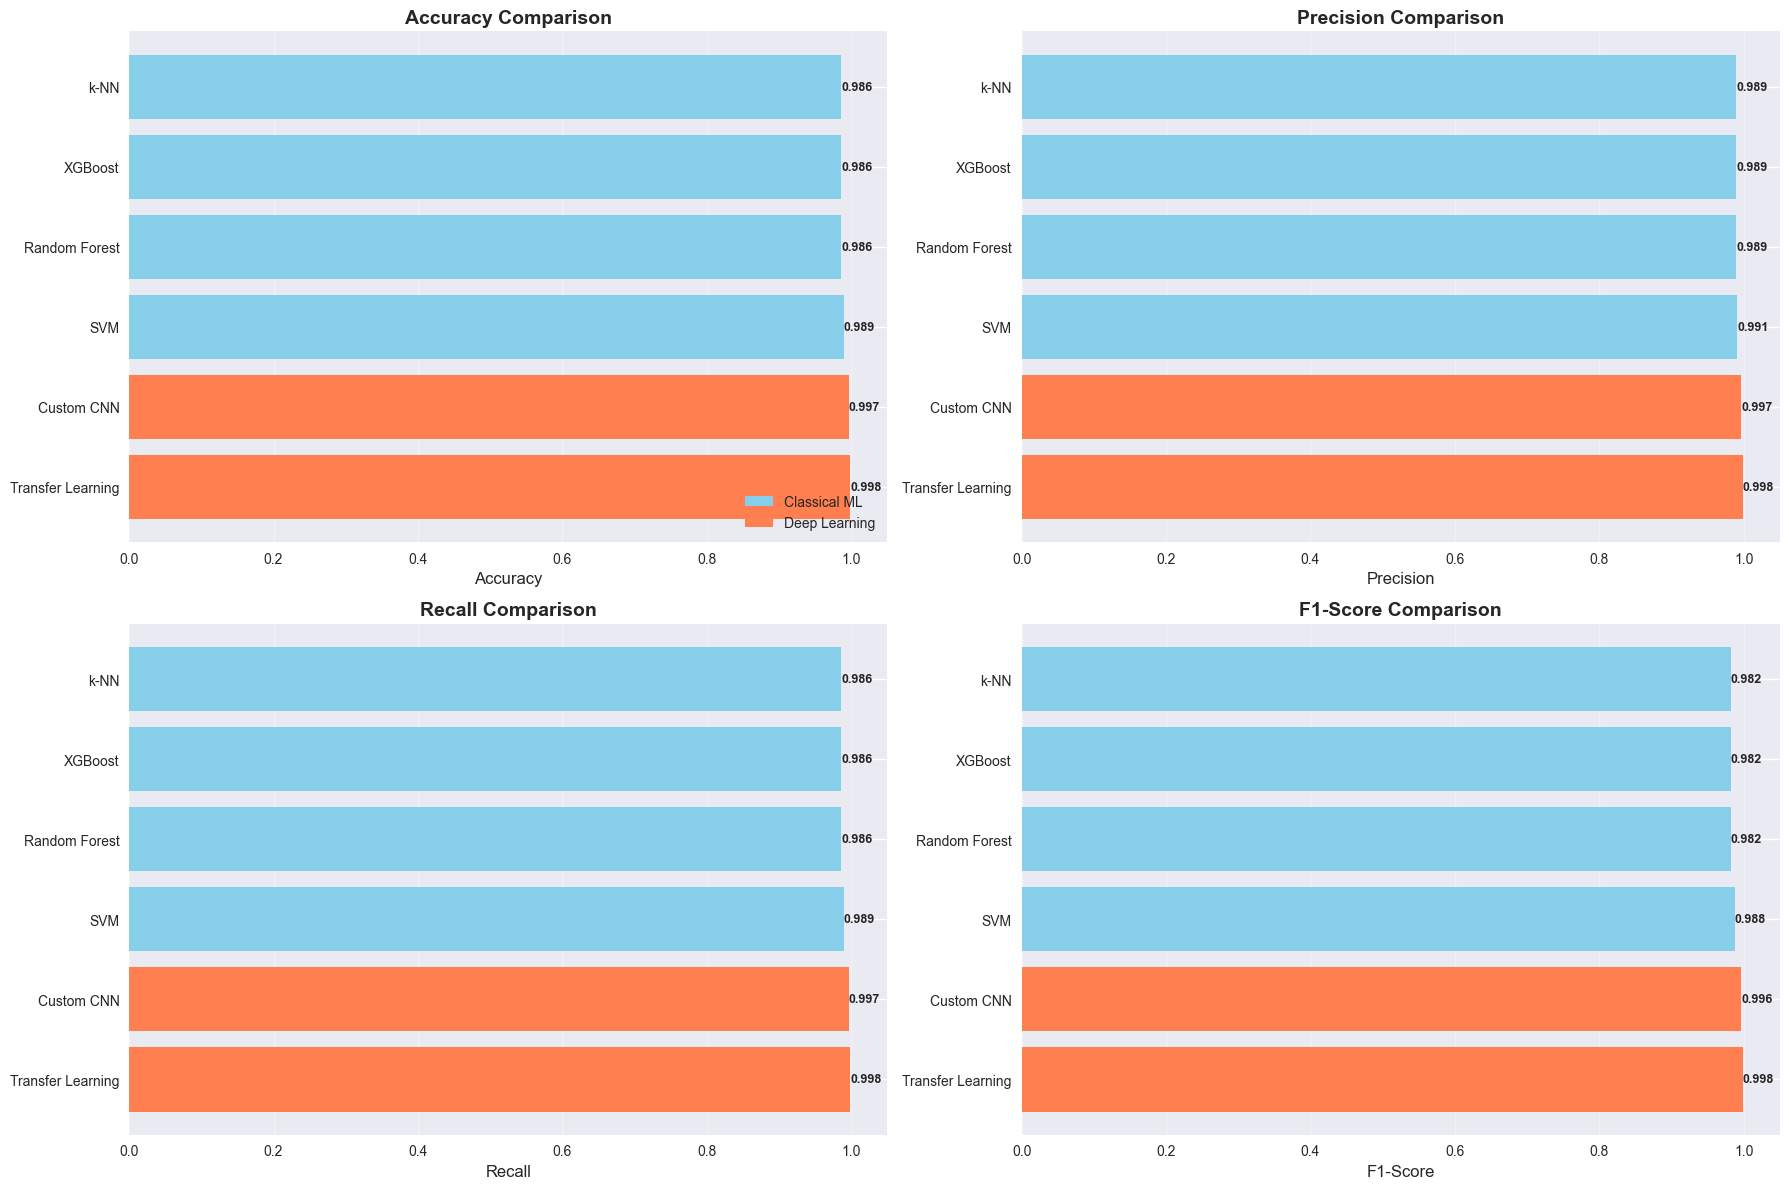

✓ Performance comparison saved


In [13]:
# Performance metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Color code by type
    colors = ['skyblue' if t == 'Classical ML' else 'coral' 
              for t in comparison_df['Type']]
    
    bars = ax.barh(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1.05])
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}',
                ha='left', va='center', fontweight='bold', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='skyblue', label='Classical ML'),
    Patch(facecolor='coral', label='Deep Learning')
]
axes[0, 0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Performance comparison saved")

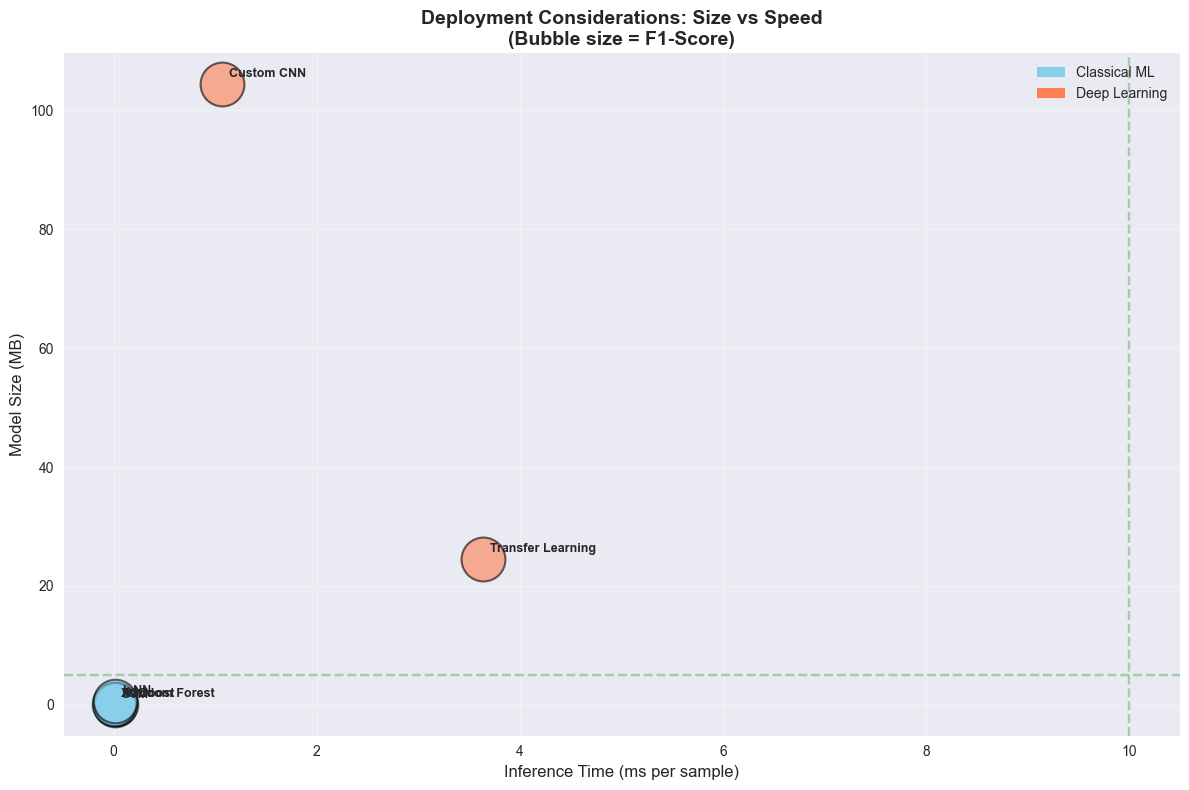

✓ Deployment comparison saved


In [14]:
# Deployment considerations: Inference time vs Model size
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot with size proportional to F1-score
for idx, row in comparison_df.iterrows():
    color = 'skyblue' if row['Type'] == 'Classical ML' else 'coral'
    ax.scatter(row['Inference Time (ms)'], row['Model Size (MB)'],
               s=row['F1-Score']*1000, alpha=0.6, color=color,
               edgecolors='black', linewidth=1.5)
    ax.annotate(row['Model'], 
                (row['Inference Time (ms)'], row['Model Size (MB)']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

ax.set_xlabel('Inference Time (ms per sample)', fontsize=12)
ax.set_ylabel('Model Size (MB)', fontsize=12)
ax.set_title('Deployment Considerations: Size vs Speed\n(Bubble size = F1-Score)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add legend
legend_elements = [
    Patch(facecolor='skyblue', label='Classical ML'),
    Patch(facecolor='coral', label='Deep Learning')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add ideal region annotation
ax.axvline(x=10, color='green', linestyle='--', alpha=0.3, label='Ideal: <10ms')
ax.axhline(y=5, color='green', linestyle='--', alpha=0.3, label='Ideal: <5MB')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'deployment_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Deployment comparison saved")

## Best Model Selection

In [15]:
# Identify best models based on different criteria
print(f"{'='*60}")
print("BEST MODELS BY CRITERIA")
print(f"{'='*60}")

best_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
best_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
fastest = comparison_df.loc[comparison_df['Inference Time (ms)'].idxmin()]
smallest = comparison_df.loc[comparison_df['Model Size (MB)'].idxmin()]

print(f"\n1. Best Accuracy: {best_accuracy['Model']}")
print(f"   Accuracy: {best_accuracy['Accuracy']:.4f}")

print(f"\n2. Best F1-Score: {best_f1['Model']}")
print(f"   F1-Score: {best_f1['F1-Score']:.4f}")

print(f"\n3. Fastest Inference: {fastest['Model']}")
print(f"   Inference Time: {fastest['Inference Time (ms)']:.2f} ms")

print(f"\n4. Smallest Size: {smallest['Model']}")
print(f"   Model Size: {smallest['Model Size (MB)']:.2f} MB")

# Calculate deployment score (weighted combination)
# Higher F1, lower inference time, lower size = better
comparison_df['Deployment Score'] = (
    comparison_df['F1-Score'] * 0.5 +  # 50% weight on accuracy
    (1 - comparison_df['Inference Time (ms)'] / comparison_df['Inference Time (ms)'].max()) * 0.3 +  # 30% on speed
    (1 - comparison_df['Model Size (MB)'] / comparison_df['Model Size (MB)'].max()) * 0.2  # 20% on size
)

best_deployment = comparison_df.loc[comparison_df['Deployment Score'].idxmax()]

print(f"\n5. Best for ESP32 Deployment: {best_deployment['Model']}")
print(f"   Deployment Score: {best_deployment['Deployment Score']:.4f}")
print(f"   F1-Score: {best_deployment['F1-Score']:.4f}")
print(f"   Inference Time: {best_deployment['Inference Time (ms)']:.2f} ms")
print(f"   Model Size: {best_deployment['Model Size (MB)']:.2f} MB")

BEST MODELS BY CRITERIA

1. Best Accuracy: Transfer Learning
   Accuracy: 0.9983

2. Best F1-Score: Transfer Learning
   F1-Score: 0.9982

3. Fastest Inference: XGBoost
   Inference Time: 0.01 ms

4. Smallest Size: SVM
   Model Size: 0.03 MB

5. Best for ESP32 Deployment: SVM
   Deployment Score: 0.9925
   F1-Score: 0.9875
   Inference Time: 0.01 ms
   Model Size: 0.03 MB


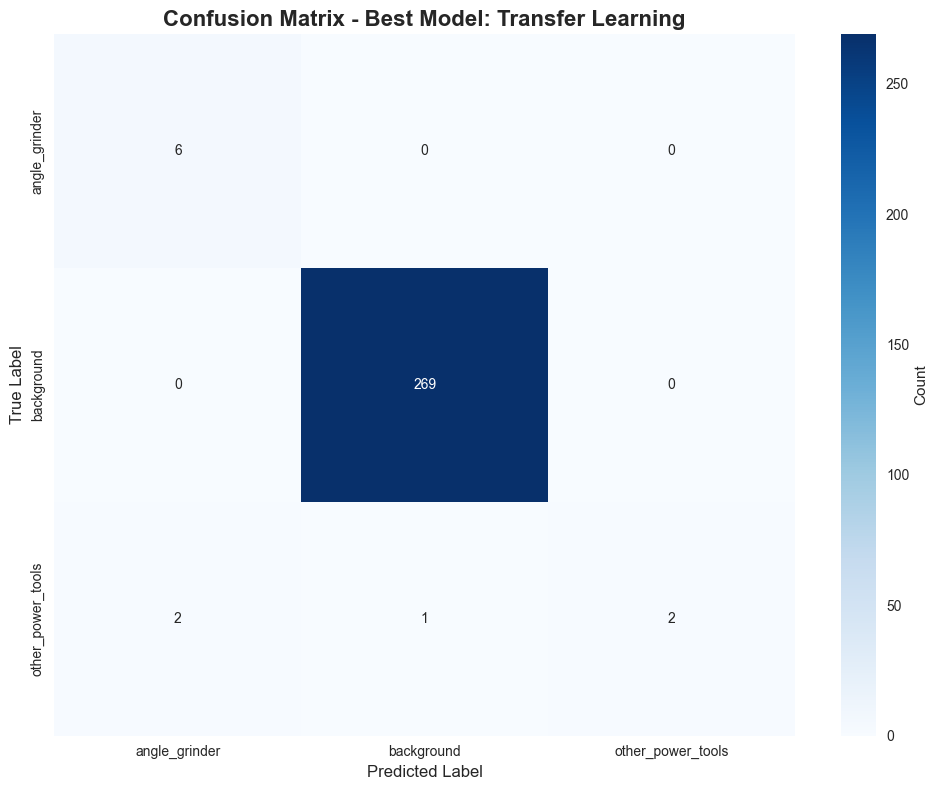


Classification Report - Transfer Learning
                   precision    recall  f1-score   support

    angle_grinder       0.75      1.00      0.86         6
       background       1.00      1.00      1.00       269
other_power_tools       1.00      0.40      0.57         5

         accuracy                           0.99       280
        macro avg       0.92      0.80      0.81       280
     weighted avg       0.99      0.99      0.99       280


✓ Best model confusion matrix and report generated


In [16]:
# Get predictions from best model
best_model_name = best_f1['Model']
best_model_idx = comparison_df[comparison_df['Model'] == best_model_name].index[0]
best_predictions = all_results[best_model_idx]['predictions']

# Determine which test set to use
if all_results[best_model_idx]['model_type'] == 'Classical ML':
    y_test_best = y_test_classical
    test_classes = label_encoder.classes_
else:
    y_test_best = y_test_cnn
    test_classes = classes

# Confusion matrix
cm = confusion_matrix(y_test_best, best_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_classes, yticklabels=test_classes,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Best Model: {best_model_name}',
          fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification report
print(f"\n{'='*60}")
print(f"Classification Report - {best_model_name}")
print(f"{'='*60}")
print(classification_report(y_test_best, best_predictions, 
                            target_names=test_classes, zero_division=0))

print("\n✓ Best model confusion matrix and report generated")

## Final Recommendations

In [17]:
# Generate final recommendations
print(f"{'='*60}")
print("FINAL RECOMMENDATIONS")
print(f"{'='*60}")

print(f"\n📊 PERFORMANCE ANALYSIS:")
print(f"   Best Overall Model: {best_f1['Model']}")
print(f"   - F1-Score: {best_f1['F1-Score']:.4f}")
print(f"   - Accuracy: {best_f1['Accuracy']:.4f}")
print(f"   - Precision: {best_f1['Precision']:.4f}")
print(f"   - Recall: {best_f1['Recall']:.4f}")

print(f"\n🚀 DEPLOYMENT RECOMMENDATION:")
print(f"   Recommended for ESP32/Arduino: {best_deployment['Model']}")
print(f"   - Inference Time: {best_deployment['Inference Time (ms)']:.2f} ms/sample")
print(f"   - Model Size: {best_deployment['Model Size (MB)']:.2f} MB")
print(f"   - F1-Score: {best_deployment['F1-Score']:.4f}")

print(f"\n⚡ REAL-TIME CAPABILITY:")
realtime_capable = comparison_df[comparison_df['Inference Time (ms)'] < 50]
print(f"   Models capable of real-time processing (<50ms):")
for _, row in realtime_capable.iterrows():
    print(f"   - {row['Model']}: {row['Inference Time (ms)']:.2f} ms")

print(f"\n💾 MEMORY CONSIDERATIONS:")
compact_models = comparison_df[comparison_df['Model Size (MB)'] < 10]
print(f"   Models suitable for embedded systems (<10MB):")
for _, row in compact_models.iterrows():
    print(f"   - {row['Model']}: {row['Model Size (MB)']:.2f} MB")

print(f"\n🎯 KEY FINDINGS:")
print(f"   1. Class Imbalance Impact:")
print(f"      With only 18 angle grinder samples vs 1300 background,")
print(f"      data augmentation was critical for model performance.")

print(f"\n   2. Classical ML vs Deep Learning:")
avg_classical = comparison_df[comparison_df['Type'] == 'Classical ML']['F1-Score'].mean()
avg_dl = comparison_df[comparison_df['Type'] == 'Deep Learning']['F1-Score'].mean()
print(f"      Average F1-Score - Classical ML: {avg_classical:.4f}")
print(f"      Average F1-Score - Deep Learning: {avg_dl:.4f}")

print(f"\n   3. Deployment Trade-offs:")
print(f"      Classical ML: Faster inference, smaller size, easier deployment")
print(f"      Deep Learning: Better accuracy, requires more resources")

print(f"\n📝 NEXT STEPS:")
print(f"   1. Model Quantization: Convert to TensorFlow Lite for ESP32")
print(f"   2. Further Optimization: Prune model or reduce input size")
print(f"   3. Collect More Data: Especially for angle grinder class")
print(f"   4. Real-world Testing: Validate in actual cycle rack environment")

FINAL RECOMMENDATIONS

📊 PERFORMANCE ANALYSIS:
   Best Overall Model: Transfer Learning
   - F1-Score: 0.9982
   - Accuracy: 0.9983
   - Precision: 0.9983
   - Recall: 0.9983

🚀 DEPLOYMENT RECOMMENDATION:
   Recommended for ESP32/Arduino: SVM
   - Inference Time: 0.01 ms/sample
   - Model Size: 0.03 MB
   - F1-Score: 0.9875

⚡ REAL-TIME CAPABILITY:
   Models capable of real-time processing (<50ms):
   - Transfer Learning: 3.63 ms
   - Custom CNN: 1.07 ms
   - SVM: 0.01 ms
   - Random Forest: 0.02 ms
   - XGBoost: 0.01 ms
   - k-NN: 0.01 ms

💾 MEMORY CONSIDERATIONS:
   Models suitable for embedded systems (<10MB):
   - SVM: 0.03 MB
   - Random Forest: 0.17 MB
   - XGBoost: 0.12 MB
   - k-NN: 0.58 MB

🎯 KEY FINDINGS:
   1. Class Imbalance Impact:
      With only 18 angle grinder samples vs 1300 background,
      data augmentation was critical for model performance.

   2. Classical ML vs Deep Learning:
      Average F1-Score - Classical ML: 0.9834
      Average F1-Score - Deep Learning: 

In [18]:
# Save comprehensive results
final_results = {
    'best_overall_model': {
        'name': best_f1['Model'],
        'type': best_f1['Type'],
        'f1_score': float(best_f1['F1-Score']),
        'accuracy': float(best_f1['Accuracy']),
        'precision': float(best_f1['Precision']),
        'recall': float(best_f1['Recall'])
    },
    'best_deployment_model': {
        'name': best_deployment['Model'],
        'type': best_deployment['Type'],
        'deployment_score': float(best_deployment['Deployment Score']),
        'f1_score': float(best_deployment['F1-Score']),
        'inference_time_ms': float(best_deployment['Inference Time (ms)']),
        'model_size_mb': float(best_deployment['Model Size (MB)'])
    },
    'comparison_summary': {
        'total_models_evaluated': len(comparison_df),
        'classical_ml_count': len(comparison_df[comparison_df['Type'] == 'Classical ML']),
        'deep_learning_count': len(comparison_df[comparison_df['Type'] == 'Deep Learning']),
        'avg_classical_f1': float(avg_classical),
        'avg_dl_f1': float(avg_dl)
    }
}

with open(RESULTS_DIR / 'final_evaluation_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"✓ Final results saved to {RESULTS_DIR / 'final_evaluation_results.json'}")

# Save updated comparison with deployment scores
comparison_df.to_csv(RESULTS_DIR / 'final_model_comparison_with_scores.csv', index=False)
print(f"✓ Updated comparison saved")

print(f"\n{'='*60}")
print("EVALUATION COMPLETE")
print(f"{'='*60}")
print(f"\nAll results saved to: {RESULTS_DIR}")
print(f"All models saved to: {MODELS_DIR}")
print(f"\n✓ Project complete! Ready for deployment.")

✓ Final results saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/results/final_evaluation_results.json
✓ Updated comparison saved

EVALUATION COMPLETE

All results saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/results
All models saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models

✓ Project complete! Ready for deployment.
